In [11]:
import pandas as pd

df = pd.read_csv('fintech_customer_churn_data.csv')

print(df.shape)
print(df.info())
print(df.head())

(4000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 4000 non-null   object 
 1   signup_date                 4000 non-null   object 
 2   age                         4000 non-null   int64  
 3   city_tier                   4000 non-null   object 
 4   segment                     4000 non-null   object 
 5   product_type                4000 non-null   object 
 6   credit_score                4000 non-null   int64  
 7   monthly_revenue             4000 non-null   float64
 8   avg_monthly_transactions    4000 non-null   float64
 9   avg_transaction_amount      4000 non-null   float64
 10  support_tickets_last_90d    4000 non-null   int64  
 11  late_payments_count         4000 non-null   int64  
 12  days_since_last_active      4000 non-null   int64  
 13  tenure_months         

churned
0    2602
1    1398
Name: count, dtype: int64


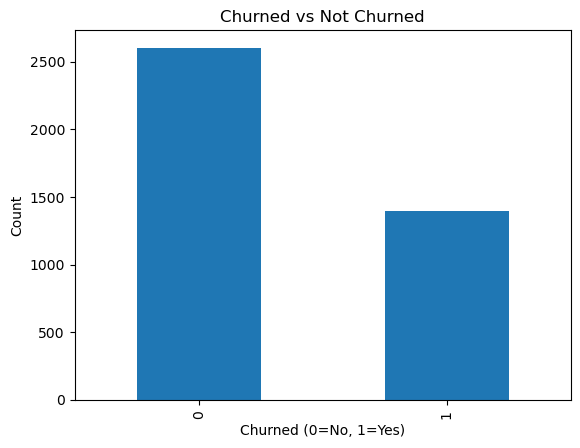

In [12]:
print(df['churned'].value_counts())

import matplotlib.pyplot as plt
df['churned'].value_counts().plot(kind='bar')
plt.title('Churned vs Not Churned')
plt.xlabel('Churned (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

segment
Basic       53.469641
Premium      9.324759
Standard    27.040816
Name: churned, dtype: float64


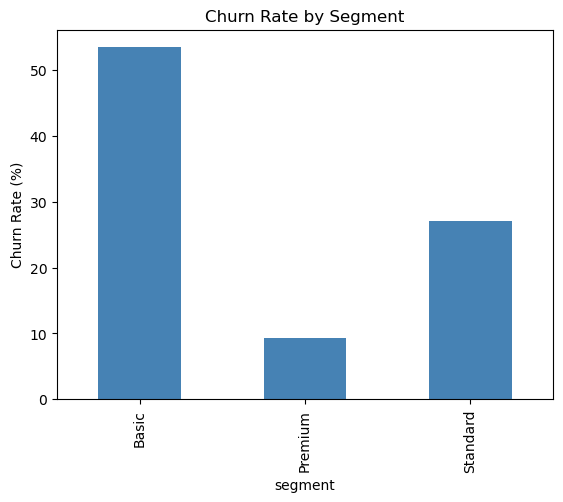

In [13]:
import seaborn as sns

# Segment-wise churn rate
segment_churn = df.groupby('segment')['churned'].mean() * 100
print(segment_churn)

segment_churn.plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

product_type
BNPL             36.909871
Credit Card      34.944751
Insurance        32.997481
Personal Loan    34.096484
Name: churned, dtype: float64


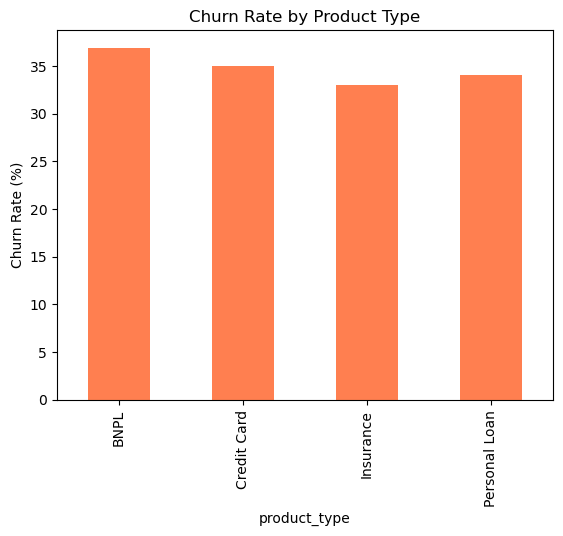

In [14]:
product_churn = df.groupby('product_type')['churned'].mean()*100
print(product_churn)
product_churn.plot(kind='bar', color='coral')
plt.title('Churn Rate by Product Type')
plt.ylabel('Churn Rate (%)')
plt.show()

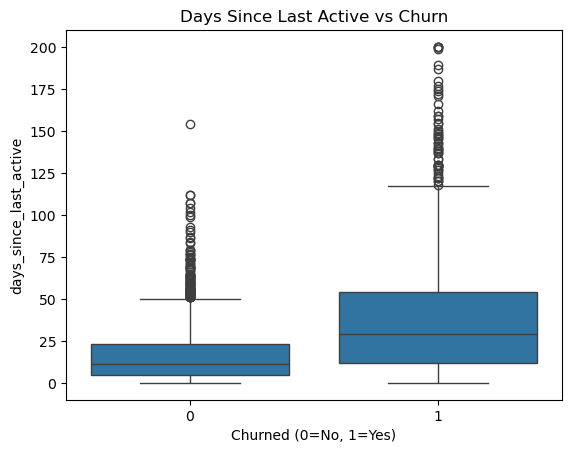

In [15]:
sns.boxplot(x='churned', y='days_since_last_active', data=df)
plt.title('Days Since Last Active vs Churn')
plt.xlabel('Churned (0=No, 1=Yes)')
plt.show()

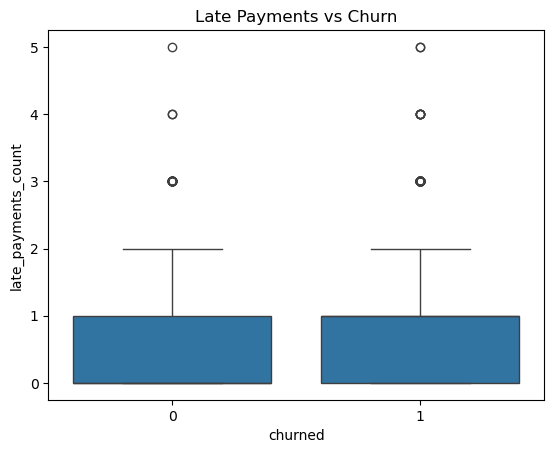

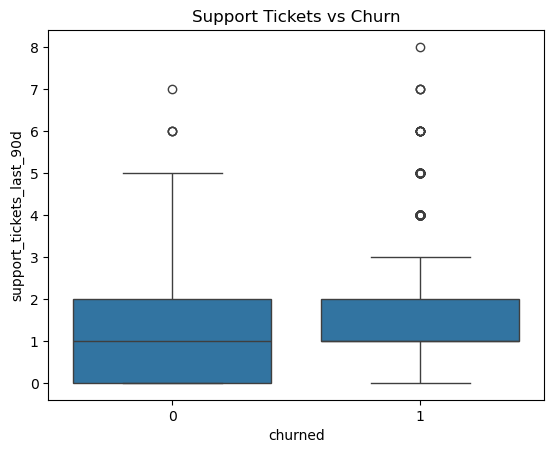

In [16]:
sns.boxplot(x='churned', y='late_payments_count', data=df)
plt.title('Late Payments vs Churn')
plt.show()

sns.boxplot(x='churned', y='support_tickets_last_90d', data=df)
plt.title('Support Tickets vs Churn')
plt.show()

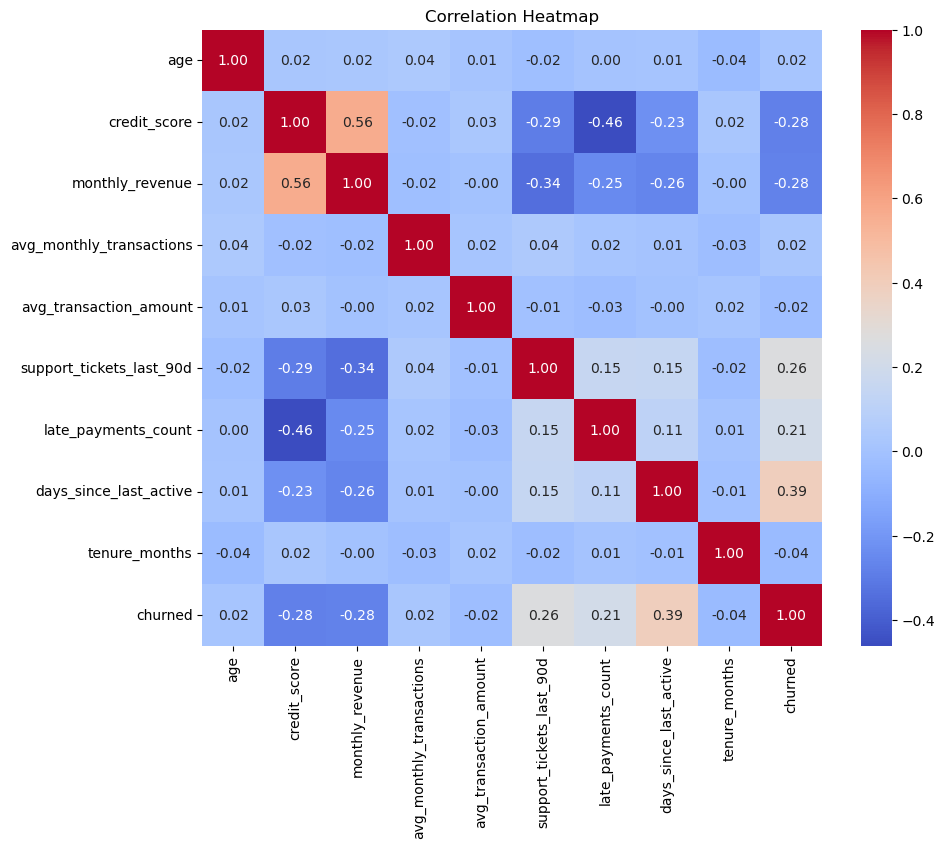

In [17]:
numeric_cols = ['age', 'credit_score', 'monthly_revenue', 'avg_monthly_transactions', 
                 'avg_transaction_amount', 'support_tickets_last_90d', 'late_payments_count',
                 'days_since_last_active', 'tenure_months', 'churned']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()